<a href="https://colab.research.google.com/github/alessiomartini/learning_statistical_learning/blob/main/1_deep_learning_theory_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Introduction

### Cristiano De Nobili - My Contacts
For any questions or doubts you can find my contacts here:

<p align="center">

[<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/Instagram_logo_2016.svg/2048px-Instagram_logo_2016.svg.png" width="20">](https://www.instagram.com/denocris/?hl=it)
[<img src="https://1.bp.blogspot.com/-Rwqcet_SHbk/T8_acMUmlmI/AAAAAAAAGgw/KD_fx__8Q4w/s1600/Twitter+bird.png" width="30">](https://twitter.com/denocris)
[<img src="https://loghi-famosi.com/wp-content/uploads/2020/04/Linkedin-Simbolo.png" width="40">](https://www.linkedin.com/in/cristiano-de-nobili/)     

</p>

or here (https://denocris.com).

### Useful Links

All notebooks can be found [here!](https://drive.google.com/drive/folders/1i3cNfzWZTNXfvkFVVIIDXjRDdSa9L9Dv?usp=sharing)

Introductory slides [here!](https://www.canva.com/design/DAEa5hLfuWg/-L2EFFfZLVuiDkmg4KiKkQ/view?utm_content=DAEa5hLfuWg&utm_campaign=designshare&utm_medium=link&utm_source=publishsharelink)

Collection of references: [here!](https://denocris.notion.site/Deep-Learning-References-0c5af2dc5c8d40baba19f1328d596fff)


### Notebook Outline

* Why PyTorch?
* Tensors and basic operations in PyTorch;
* Automatic Differentiation;

### Why PyTorch?


[PyTorch](https://pytorch.org/) is amongst the most widely used libraries for performing machine learning research and numerical computations. PyTorch is similar to NumPy, with the additional benefit that PyTorch allows you to perform your computations on CPUs and GPUs without any change to your code. PyTorch also makes it easy to distribute your computation across multiple devices or machines. One of the most important features of PyTorch is automatic differentiation. It allows computing the gradients of your functions analytically in an efficient manner which is crucial for training machine learning models using gradient descent method.

So, we will now see these PyTorch useful classes (from PyTorch Tutorials):

  -  ``torch.Tensor`` - A *multi-dimensional array* with support for autograd
     operations like ``backward()``. Also *holds the gradient* w.r.t. the
     tensor.
  -  ``nn.Module`` - Neural network module. *Convenient way of
     encapsulating parameters*, with helpers for moving them to GPU,
     exporting, loading, etc.
  -  ``nn.Parameter`` - A kind of Tensor, that is *automatically
     registered as a parameter when assigned as an attribute to a*
     ``Module``.
  -  ``autograd.Function`` - Implements *forward and backward definitions
     of an autograd operation*. Every ``Tensor`` operation creates at
     least a single ``Function`` node that connects to functions that
     created a ``Tensor`` and *encodes its history*.

### Packages

In [1]:
%matplotlib inline

import random
import numpy as np
from matplotlib import pyplot as plt


import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset

In [2]:
#device = torch.device('cpu')
device = torch.device('cuda') # Uncomment this to run on GPU

In [3]:
!nvidia-smi

Fri Jul 17 15:45:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# set the seed for reproducibility: built-in python, numpy, and pytorch
seed = 172
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) # works for all devices (CPU and GPU)

### What is a tensor?

Like NumPy, PyTorch provides its own multidimensional array class, called `Tensor`. `Tensors` are essentially the equivalent of NumPy `ndarrays`. We can say that:

* `Tensor` draws a lot of methods from NumPy
* `Tensor` has CUDA support


In [5]:
# torch.tensor vs np.array
x = torch.tensor([[1.1,5,4],[3,2,1]])

y = np.array([[1.1,5,4],[3,2,1]])

In [6]:
x.dtype, y.dtype

(torch.float32, dtype('float64'))

`torch` already thinks with Machine Learning in mind as the Tensor is implicitly converted to dtype float32, while NumPy makes no such assumption. Since in deep learning memory is always a bottleneck. Especially when you are dealing with large volume of data and using a GPU with limited memory. I would recommend using `tf.float32` for a better speed with the price of a possible negligible loss of precision.

For more info on Tensor data types, check [this page](https://pytorch.org/docs/stable/tensors.html).

Note that if we put integers, torch.tensor infers the type

In [7]:
x = torch.tensor([[1,5,4],[3,2,1]])
x.dtype

torch.int64

Tensors are simply multidimensional arrays

* A scalar (a number) is a $0-dim$ array;
* a vector is a $1-dim$ array;
* a matrix is a $2-dim$ array;
* ...

<center>  <img src="https://drive.google.com/uc?export=view&id=1BvK6ZGM7x_8x2LRfoVXvpaIE_mTycWqe" width="650" height="400"> </center>


As in NumPy, we can call the `.shape` attribute to get the shape of the structures. Moreover, Tensors have also the `.size()` method which is analogous to `.shape`.




In [8]:
x = torch.tensor([[1,5,4],[3,2,1]])


In [9]:
x.shape, x.size()

(torch.Size([2, 3]), torch.Size([2, 3]))

Let go step by step

In [10]:
s = torch.tensor(3.14156)
s.size()

torch.Size([])

In [11]:
v = torch.tensor([1,2,3])
v.size()

torch.Size([3])

In [12]:
m = torch.tensor([[1,2,3], [3,4,5]])
m.size()

torch.Size([2, 3])

In [13]:
t = torch.tensor([[[1,2,3], [4,5,6]], [[7,8,9], [10,11,12]]])
t.size()

torch.Size([2, 2, 3])

In [14]:
s = torch.tensor(1)
v = torch.tensor([1,2,3])
m = torch.tensor([[1,2], [3,4]])
t = torch.tensor([[[1,2,3], [4,5,6]], [[7,8,9], [10,11,12]]])

print(s)
print(v)
print(m)
print(t)

tensor(1)
tensor([1, 2, 3])
tensor([[1, 2],
        [3, 4]])
tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])


We can extract the size of the tensor by simply

In [15]:
s.size(), v.size(), m.size(), t.size()

(torch.Size([]), torch.Size([3]), torch.Size([2, 2]), torch.Size([2, 2, 3]))

In [16]:
t1 = torch.tensor([0,1])
print(t1.size(), '-> (axis=0, )')

t2 = torch.tensor([[0,1],      [2,3],       [4,5],        [6,7]])
# from left to right, the outer and inner dimension
print(t2.size(), '-> (axis=0, axis=1)')

t3 = torch.tensor([[[0,1,2],[3,4,5]],   [[6,7,8],[9,10,11]],    [[13,14,15],[16,17,18]],     [[19,20,21],[22,23,24]]])
# from left to right, the outer and inner dimension
print(t3.size(), '-> (axis=0, axis=1, axis=2)')

torch.Size([2]) -> (axis=0, )
torch.Size([4, 2]) -> (axis=0, axis=1)
torch.Size([4, 2, 3]) -> (axis=0, axis=1, axis=2)


We can also generate a random vector of arbitrary size

In [17]:
d = torch.rand([3, 2])   # torch.randn([3, 3, 4]) #
d

tensor([[0.2469, 0.2080],
        [0.8997, 0.9753],
        [0.8461, 0.7945]])

In [18]:
d = torch.rand([3, 3, 4])   # torch.randn([3, 3, 4]) #
d

tensor([[[0.9302, 0.0049, 0.4042, 0.1300],
         [0.2102, 0.9829, 0.0334, 0.4363],
         [0.3250, 0.3079, 0.2295, 0.1500]],

        [[0.6592, 0.3632, 0.8722, 0.0489],
         [0.3148, 0.4832, 0.0953, 0.2106],
         [0.8527, 0.2870, 0.6727, 0.0772]],

        [[0.1950, 0.7856, 0.5628, 0.3543],
         [0.9807, 0.0153, 0.7193, 0.6900],
         [0.6834, 0.6598, 0.5051, 0.7663]]])

#### Slice of a Tensor

In [19]:
l = [0,1,2,3,4,5,6]
l[2:6]

[2, 3, 4, 5]

In [20]:
t3 = torch.tensor([[[0,1,2],[3,4,5]],    [[6,7,8],[9,10,11]],    [[13,14,15],[16,17,18]],     [[19,20,21],[22,23,24]]])
t3.size()

torch.Size([4, 2, 3])

In [21]:
# Select some slices
# Ex: from axis-0 select the first 2 out of 4 elements, from axis-1 the last element, from axis-2 the first two.
t3[0:2, 1:2,  0:2]

tensor([[[ 3,  4]],

        [[ 9, 10]]])

#### Operation with tensors

When you have more than one tensor you can perform algebric operations between them. Here matrix multiplication

In [22]:
z1 = torch.randn([3, 5])  # random normal
z2 = torch.randn([5, 4])

# first way
print(z1 @ z2, "Matrix multiplication: with '@'")

# second way
print(torch.matmul(z1, z2), "Matrix multiplication: with torch.matmul")

# third way
print(z1.matmul(z2), "Matrix multiplication: with Tensor.matmul")

tensor([[-3.4140, -1.1633, -1.1034,  0.2730],
        [ 2.4320,  2.8921,  2.0479,  2.6199],
        [-1.3882,  0.5998, -0.0675, -1.0088]]) Matrix multiplication: with '@'
tensor([[-3.4140, -1.1633, -1.1034,  0.2730],
        [ 2.4320,  2.8921,  2.0479,  2.6199],
        [-1.3882,  0.5998, -0.0675, -1.0088]]) Matrix multiplication: with torch.matmul
tensor([[-3.4140, -1.1633, -1.1034,  0.2730],
        [ 2.4320,  2.8921,  2.0479,  2.6199],
        [-1.3882,  0.5998, -0.0675, -1.0088]]) Matrix multiplication: with Tensor.matmul


Don't mistake `@` and `*` as the latter is the Hadamard (element-by-element) product!



In [23]:
z1*z1
#z1 * z2 # this gives an Exception


tensor([[1.0147e+00, 2.1133e-01, 8.3286e-01, 2.8867e-01, 4.8181e-02],
        [4.1150e-01, 2.0872e-02, 2.8725e+00, 1.1873e+00, 7.0016e-01],
        [6.6419e-04, 1.1683e+00, 1.4029e-02, 5.0814e-01, 1.3456e+00]])

Generally, the "regular" arithmetic operators for Python act as element-wise operators in Tensors (as in ndarrays)


In [24]:
z3 = torch.Tensor([[2,4,6,8,10],[1,3,5,7,9]])
z4 = torch.Tensor([[2,2,2,2,2],[1,1,1,1,1]])

print(z3 % z4, "z1 % z3 (remainder of integer division)")
print(z3 // z4, "z3 // z1 (integer division)")

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) z1 % z3 (remainder of integer division)
tensor([[1., 2., 3., 4., 5.],
        [1., 3., 5., 7., 9.]]) z3 // z1 (integer division)


One important aspect to keep in mind is that a tensor has several dimensions, so we need to specify along what specific axis we want to perform our operation.

In [25]:
t4 = torch.tensor([[0,1], [2,3]])

print('Sum along axis 0: ', torch.sum(t4, axis=0))
print('Sum along axis 1: ', torch.sum(t4, axis=1))
# axis -1 is the inner one
print('Sum along axis -1: ', torch.sum(t4, axis=-1))

Sum along axis 0:  tensor([2, 4])
Sum along axis 1:  tensor([1, 5])
Sum along axis -1:  tensor([1, 5])


Transposition

In [26]:
z1 = torch.rand([4, 5])
print("z1")
print("shape", z1.shape)
print(z1)

# transposition
z2 = z1.T

print("\nz2")
print("shape", z2.shape)
print(z2)

z1
shape torch.Size([4, 5])
tensor([[0.2275, 0.1129, 0.2894, 0.1028, 0.1243],
        [0.8725, 0.2098, 0.9223, 0.4604, 0.9713],
        [0.1580, 0.9826, 0.4758, 0.8646, 0.0668],
        [0.3187, 0.4162, 0.7541, 0.1914, 0.2498]])

z2
shape torch.Size([5, 4])
tensor([[0.2275, 0.8725, 0.1580, 0.3187],
        [0.1129, 0.2098, 0.9826, 0.4162],
        [0.2894, 0.9223, 0.4758, 0.7541],
        [0.1028, 0.4604, 0.8646, 0.1914],
        [0.1243, 0.9713, 0.0668, 0.2498]])


Vector multiplication

In [27]:
vec1 = torch.rand((5,)) # torch.tensor([1,2,3])
vec2 = torch.rand((5,)) # torch.tensor([4,5,6])

print(vec1, "vec1")
print(vec2, "vec2")

print(vec1 @ vec2, "I can use '@' even if the two vectors aren't conformable")

print(vec1.unsqueeze(0) @ vec2.unsqueeze(-1))

print(torch.matmul(vec1, vec2))

print(torch.dot(vec1, vec2))

tensor([0.3625, 0.0263, 0.0519, 0.9678, 0.5962]) vec1
tensor([0.9451, 0.3874, 0.6686, 0.8693, 0.2951]) vec2
tensor(1.4048) I can use '@' even if the two vectors aren't conformable
tensor([[1.4048]])
tensor(1.4048)
tensor(1.4048)


#### More linear algebra

In [28]:
z3 = torch.Tensor([[2,4,6,8,10],[1,3,5,7,9]])

z3_norm = z3.norm() # equivalent z3.norm(dim=1)
# np.sqrt(2**2+4**2+6**2+8**2+10**2 + 1**2+3**2+5**2+7**2+9**2)
z3_norm

tensor(19.6214)

In [29]:
z3_norm = z3.norm(dim=0)
z3_norm

tensor([ 2.2361,  5.0000,  7.8102, 10.6301, 13.4536])

To "disentangle" the scalar from a Tensor use the .item() method.



In [30]:
z3_norm[0].item()


2.2360680103302

Conversion PyTorch <-> Numpy

In [31]:
y_numpy = np.random.rand(3,5)
y_torch = torch.from_numpy(y_numpy)
print(y_torch, "y converted to torch.Tensor")

x = torch.rand(6,4)
x_numpy = x.numpy()
print(x_numpy, "x converted to numpy.ndarray")

tensor([[0.1494, 0.1246, 0.3197, 0.6755, 0.6110],
        [0.8797, 0.3087, 0.3216, 0.2548, 0.4557],
        [0.6909, 0.7239, 0.1488, 0.6752, 0.1511]], dtype=torch.float64) y converted to torch.Tensor
[[0.6691805  0.7928066  0.5950892  0.6559825 ]
 [0.72723967 0.33440036 0.98243034 0.14510173]
 [0.7804562  0.7076425  0.44562387 0.5533622 ]
 [0.87600553 0.9286492  0.22740787 0.9207345 ]
 [0.25603104 0.73193926 0.64919305 0.23409432]
 [0.5695931  0.83621365 0.38729757 0.49458474]] x converted to numpy.ndarray


#### Memory on RAM

We can get the total number of elements in a Tensor via the `numel()` method



In [32]:
t3 = torch.tensor([[[0.000001,1,2],[3,4,5]],   [[6,7,8],[9,10,11]],    [[13,14,15],[16,17,18]],     [[19,20,21],[22,23,24]]])
t3.numel()

24

In [33]:
t3.dtype

torch.float32

`element_size()` returns the size in bytes of an individual element.



In [34]:
t3.element_size()

4

Hence, we can quickly calculate the size (byte) of the Tensor within the RAM

In [35]:
t3.numel() * t3.element_size()

96

### Automatic Differentiation

One of the advantage of PyTorch over NumPy is its automatic differentiation which is very useful in optimization applications, such as neural network backpropagation.


#### Example 1 (simple)

Suppose to have a composite function which is a chain of two functions: g(u(x)). To compute the derivative of g with respect to x we can use the chain rule:

$$\frac{dg}{dx} = \frac{dg}{du} \cdot \frac{du}{dx}$$

PyTorch can analytically compute the derivatives for us.

To compute the derivatives in PyTorch first we create a tensor and set its `requires_grad = true`. We can use tensor operations to define our functions. Let us give the following example

In [36]:
x = torch.tensor(0.5, requires_grad=True)

def u(x):
  return x * x

def g(u):
  return -2*u

Our composite function is $g(x) = -2 x^2$, whose derivative is $dg/dx = - 4 x$. At the point $x = 0.5$ its value is $-2$. Let us check this result

In [37]:
dg_dx = torch.autograd.grad(g(u(x)), x)[0]
print(dg_dx)

tensor(-2.)


#### Example 2

Assume that we have samples from a curve (say $f(x) = 3x^2 + 5$) and we want to estimate f(x) based on these samples. We define a parametric function $g(x, w) = w_0 x^2 + w_1 x + w_2$, which is a function of the input x and parameters w. The goal is then to find the parameters such that $g(x, w) ≈ f(x)$.

Note that $g(x, w)$ can be written as:
$$
g(x, w)=
\begin{pmatrix}
    x^2 & x & 1
\end{pmatrix}
\cdot
\begin{pmatrix}
    w_0 \\ w_1 \\ w_2
\end{pmatrix}
$$

In [38]:
# Assuming we know that the desired function is a polynomial of 2nd degree, we
# allocate a vector of size 3 to hold the coefficients and initialize it with
# random noise.
w = torch.tensor(torch.randn([3, 1]), requires_grad=True)

# We use the Adam optimizer with learning rate set to 0.1 to minimize the loss.
opt = torch.optim.Adam([w], 0.1)

def model(x):
  g = torch.stack([ x*x, x , torch.ones_like(x)], 1)
  pred = torch.squeeze(g @ w, 1)
  return pred

def compute_loss(y, pred):
    # The loss is defined to be the mean squared error distance between our
    # estimate of y and its true value.
    loss = torch.nn.functional.mse_loss(y, pred)
    return loss

def data_generator():
  # Generate some training data (between -10 and 10) based on the true function
  x = torch.rand(100) * 20 - 10
  y = 3*x*x + 5
  return x, y

def train_step():
  x, y = data_generator()

  pred = model(x) #g(x,w)

  loss = compute_loss(y, pred)

  # Don't worry! We will see in full details these three lines later.
  # For the moment, just know that they are computing derivatives.
  opt.zero_grad()
  loss.backward()
  opt.step()

for _ in range(1000):
    train_step()

print(w.detach().numpy())


/tmp/ipykernel_674/2388009829.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(torch.randn([3, 1]), requires_grad=True)


[[ 3.0011976e+00]
 [-4.6608906e-04]
 [ 4.9313664e+00]]


##### Exercise

Assume that we have samples from a curve (say $f(x) = 1.2x^4 + 4.5x^2 + 2x + 2$) and we want to estimate f(x) based on these samples. We define a parametric function $g(x, w)$, which is a function of the input x and parameters w. The goal is then to find the parameters such that $g(x, w) ≈ f(x)$. Collect and plot loss values during trainig. In addition, plot the value of w_0 during training.

[[1.2000432e+00]
 [8.7453617e-04]
 [4.4960308e+00]
 [1.9984818e+00]
 [2.0606787e+00]]


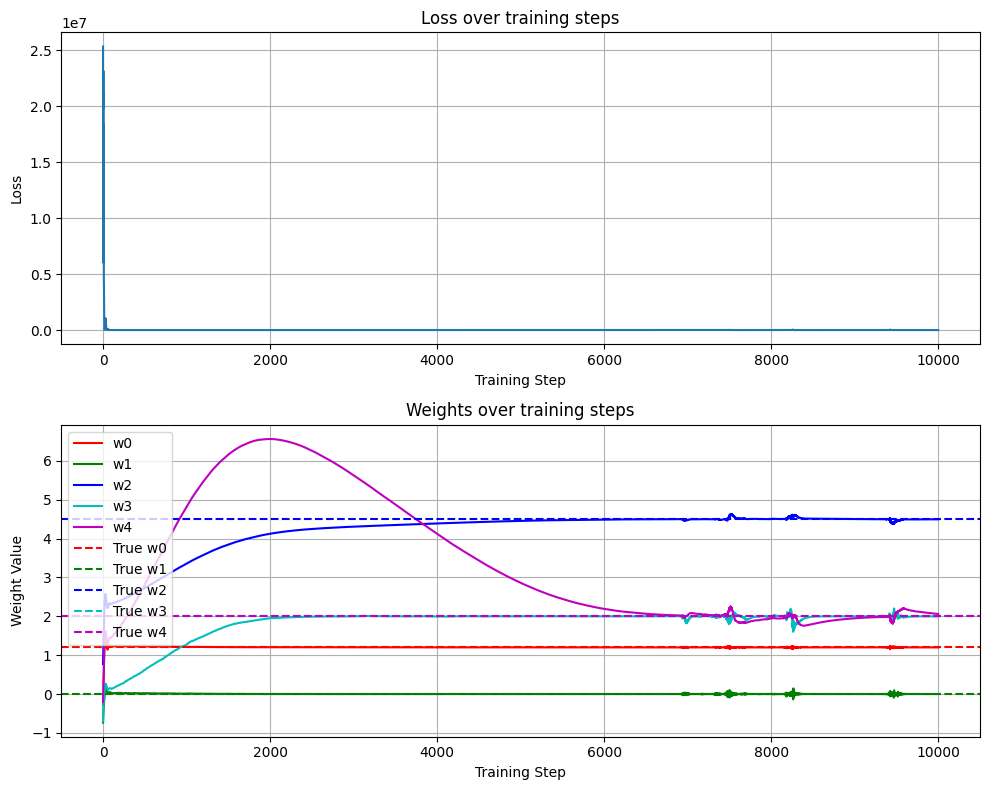

In [43]:
# Assuming we know that the desired function is a polynomial of 2nd degree, we
# allocate a vector of size 5 to hold the coefficients and initialize it with
# random noise.
w = torch.randn([5, 1], requires_grad=True)

# We use the Adam optimizer with learning rate set to 0.1 to minimize the loss.
opt = torch.optim.Adam([w], 0.1)

def model(x):
  g = torch.stack([ x*x*x*x, x*x*x, x*x, x , torch.ones_like(x)], 1)
  pred = torch.squeeze(g @ w, 1)
  return pred

def compute_loss(y, pred):
    # The loss is defined to be the mean squared error distance between our
    # estimate of y and its true value.
    loss = torch.nn.functional.mse_loss(y, pred)
    return loss

def data_generator():
  # Generate some training data (between -10 and 10) based on the true function
  x = torch.rand(100) * 20 - 10 # 100 points per training
  y = 1.2*x*x*x*x + 4.5*x*x + 2*x + 2
  return x, y

def train_step():
  x, y = data_generator()

  pred = model(x) #g(x,w)

  loss = compute_loss(y, pred)

  # Don't worry! We will see in full details these three lines later.
  # For the moment, just know that they are computing derivatives.
  opt.zero_grad()
  loss.backward()
  opt.step()

  # Return loss (scalar) and detached flattened weights (PyTorch tensor)
  return loss.item(), w.detach().clone().flatten()

N = 10000 # number of trainig steps (each of 100 points)

# Initialize lists to store metrics
loss_history = []
w_history = [] # This will store lists of [w0, w1, w2, w3, w4] as PyTorch tensors

for i in range(N):
    current_loss, current_w = train_step()
    loss_history.append(current_loss)
    w_history.append(current_w)

print(w.detach().numpy())

# Convert histories to PyTorch tensors first
loss_tensor = torch.tensor(loss_history)
w_tensor = torch.stack(w_history)

# Convert to numpy arrays for plotting with matplotlib
loss_plot = loss_tensor.numpy()
w_plot = w_tensor.numpy()

# True weights for comparison
true_weights = [1.2, 0.0, 4.5, 2.0, 2.0]  # in order: w0, w1, w2, w3, w4

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

# Plotting loss
axes[0].plot(range(N), loss_plot)
axes[0].set_title('Loss over training steps')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Plotting weights
axes[1].plot(range(N), w_plot[:, 0], color='r', label='w0')
axes[1].plot(range(N), w_plot[:, 1], color='g', label='w1')
axes[1].plot(range(N), w_plot[:, 2], color='b', label='w2')
axes[1].plot(range(N), w_plot[:, 3], color='c', label='w3')
axes[1].plot(range(N), w_plot[:, 4], color='m', label='w4')

# Plot true weights
axes[1].axhline(y=true_weights[0], color='r', linestyle='--', label='True w0')
axes[1].axhline(y=true_weights[1], color='g', linestyle='--', label='True w1')
axes[1].axhline(y=true_weights[2], color='b', linestyle='--', label='True w2')
axes[1].axhline(y=true_weights[3], color='c', linestyle='--', label='True w3')
axes[1].axhline(y=true_weights[4], color='m', linestyle='--', label='True w4')

axes[1].set_title('Weights over training steps')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Weight Value')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
